# <u><b>DECODE LABS</b></u>
# <u>Project 1 - Advanced EDA And Feature Engineering</u>
## <u>Objective :-</u>

The objective of this project is to clean and transform a raw e-commerce dataset into a high-quality, analysis-ready dataset through Exploratory Data Analysis (EDA), missing value treatment, outlier detection, and feature engineering. The processed dataset will serve as a reliable foundation for future analytical and machine learning tasks.

## Importing Necessary Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [30]:
df = pd.read_excel("../data/Dataset for Data Analytics.xlsx")

In [31]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Exploring Data

In [32]:
print("\nShape Of DataFrame :", df.shape,"\n")


Shape Of DataFrame : (1200, 14) 



In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [34]:
df.describe(include="number")

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [35]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df["CouponCode"].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

## Task - 1 (Handling Missing Values)

In [38]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [39]:
df["CouponCode"].isnull().sum()

np.int64(0)

In [40]:
df["CouponCode"].value_counts()

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

#### Observation :-

Only CouponCode had missing values (309); these represent orders where no coupon was used, not unknown data.

#### Approach :-

Mode imputation was avoided since it would falsely indicate coupon usage. Missing values were replaced with "No Coupon" instead, preserving the true meaning.

#### Conclusion :-

All 309 missing values were resolved by labeling them "No Coupon" rather than imputing a value, ensuring the dataset accurately reflects real coupon usage instead of fabricating it.

## Task - 2 (Handling Outliers)

In [41]:
numeric_columns = list(df.select_dtypes(include="number").columns)
numeric_columns

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

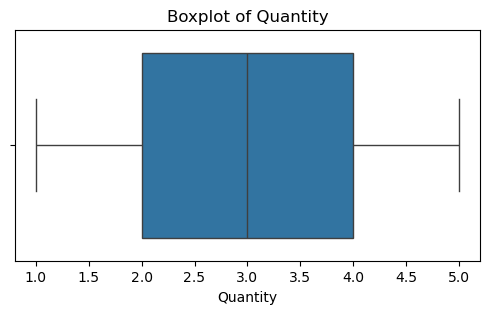

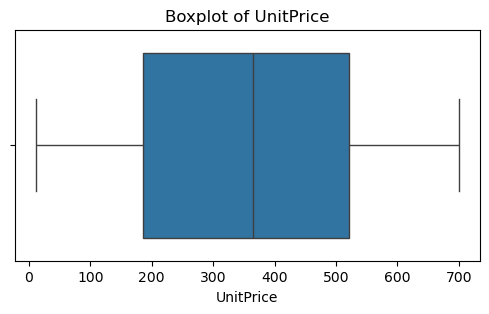

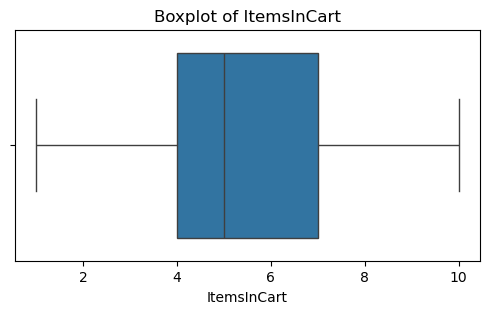

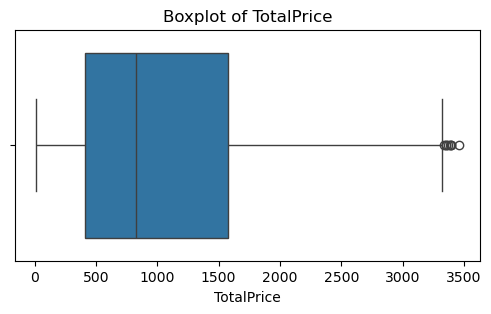

In [42]:
for col in numeric_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [43]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerBound = Q1 - (1.5 * IQR)
    upperBound = Q3 + (1.5 * IQR)
    outliers = df[
        (df[col] < lowerBound) | 
        (df[col] > upperBound)
    ]
    print(f"{col}")
    print(f"Lower Bound: {lowerBound:.2f}")
    print(f"Upper Bound: {upperBound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

Quantity
Lower Bound: -1.00
Upper Bound: 7.00
Number of Outliers: 0
----------------------------------------
UnitPrice
Lower Bound: -317.20
Upper Bound: 1024.83
Number of Outliers: 0
----------------------------------------
ItemsInCart
Lower Bound: -0.50
Upper Bound: 11.50
Number of Outliers: 0
----------------------------------------
TotalPrice
Lower Bound: -1341.41
Upper Bound: 3330.41
Number of Outliers: 8
----------------------------------------


#### Observation :-

Outliers were identified using the **Interquartile Range (IQR)** method for all numerical columns in the dataset. Boxplots were also used to visualize the distribution of each numerical feature.

The analysis showed:

- **Quantity:** No outliers detected.
- **UnitPrice:** No outliers detected.
- **ItemsInCart:** No outliers detected.
- **TotalPrice:** A small number of potential outliers were detected.

#### -> For TotalPrice

In [44]:
Q1_TP = df["TotalPrice"].quantile(0.25)
Q3_TP = df["TotalPrice"].quantile(0.75)

IQR_TP = Q3_TP - Q1_TP

lower = Q1_TP - (1.5 * IQR_TP)
upper = Q3_TP + (1.5 * IQR_TP)

totalprice_outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

totalprice_outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No Coupon,Facebook,3390.95


#### Decision :-

Flagged TotalPrice outliers were examined and found to be valid high-value purchases, not data errors. Since they reflect real customer behavior, they were retained rather than removed or modified.

#### Conclusion :-

No outlier treatment was applied. The IQR method (across Quantity, UnitPrice, ItemsInCart, and TotalPrice) flagged only TotalPrice outliers, and these were confirmed as legitimate large orders rather than errors — so the original values were retained to preserve accurate business information.

## Task - 3  (Feature Engineering)

In [45]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

### Feature 1 - 3 :  Date Extraction

In [46]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()

In [47]:
df[["OrderID", "CustomerID", "Date", "Year", "Month", "MonthName"]].head()

,OrderID,CustomerID,Date,Year,Month,MonthName
0,ORD200000,C72649,2023-01-04,2023,1,January
1,ORD200001,C75739,2024-08-23,2024,8,August
2,ORD200002,C81728,2024-02-27,2024,2,February
3,ORD200003,C33540,2023-10-15,2023,10,October
4,ORD200004,C81840,2025-05-08,2025,5,May


#### Conclusion :-
The Year, Month, and MonthName features were extracted from the Date column to make the dataset more useful for analysis. Year helps distinguish data from different years, while Month and MonthName can be used to analyze monthly trends and seasonal patterns.

### Feature 4 : Spending Category

In [48]:
df["SpendingCategory"] = pd.qcut(
    df["TotalPrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [49]:
df["SpendingCategory"].value_counts()

SpendingCategory
Low       400
Medium    400
High      400
Name: count, dtype: int64

In [50]:
df[["CustomerID", "TotalPrice", "SpendingCategory"]].head()

,CustomerID,TotalPrice,SpendingCategory
0,C72649,2853.10,High
1,C75739,302.70,Low
2,C81728,2753.40,High
3,C33540,273.19,Low
4,C81840,2504.04,High


#### Conclusion :-
TotalPrice was segmented into Low/Medium/High tiers using quantile-based binning (pd.qcut), producing a perfectly balanced split (400/400/400).

### Feature 5 : Coupon Usage Indicator

In [51]:
df["CouponUsed"] = np.where(df["CouponCode"] == "No Coupon", "No", "Yes")

In [52]:
df[["CustomerID", "CouponCode", "CouponUsed"]].head(10)

,CustomerID,CouponCode,CouponUsed
0,C72649,SAVE10,Yes
1,C75739,SAVE10,Yes
2,C81728,FREESHIP,Yes
3,C33540,SAVE10,Yes
4,C81840,SAVE10,Yes
5,C37249,SAVE10,Yes
6,C83492,SAVE10,Yes
7,C41460,FREESHIP,Yes
8,C26817,No Coupon,No
9,C31946,SAVE10,Yes


#### Conclusion :-
A binary flag was derived from the cleaned CouponCode column to quickly identify coupon vs. non-coupon orders, simplifying coupon-usage analysis without needing to check exact codes.

### Feature 6 :- Cart Abandonment Gap

In [53]:
df["CartAbandonmentGap"] = df["ItemsInCart"] - df["Quantity"]

In [54]:
df["CartAbandonmentGap"].describe()

count    1200.000000
mean        2.539167
std         1.735697
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: CartAbandonmentGap, dtype: float64

In [55]:
df[["CustomerID", "ItemsInCart", "Quantity", "CartAbandonmentGap"]].head()

,CustomerID,ItemsInCart,Quantity,CartAbandonmentGap
0,C72649,7,5,2
1,C75739,3,2,1
2,C81728,8,5,3
3,C33540,5,1,4
4,C81840,8,4,4


#### Conclusion :-
Calculated as ItemsInCart - Quantity, this feature captures items added to the cart but not purchased -- a potential abandonment signal.

#### Storing Cleaned Data

In [56]:
df.to_csv("../data/Cleaned_Dataset.csv", index=False)

## <u>Project Summary</u>

### Objective

The objective of this project was to clean and preprocess the dataset by handling missing values, detecting and analyzing outliers, and performing feature engineering to improve the quality and usability of the data for future analysis and machine learning tasks.

### Work Completed

#### 1. Missing Value Handling

- Checked the dataset for missing values and duplicate records.
- Identified missing values only in the `CouponCode` column.
- Replaced missing values with **"No Coupon"** because they represent customers who did not use any coupon rather than missing or incorrect data.

#### 2. Outlier Detection

- Applied the **Interquartile Range (IQR)** method to all numerical features.
- Visualized the distributions using boxplots.
- Investigated the detected outliers and concluded that they represented legitimate high-value transactions.
- No outlier treatment was applied to preserve valid business information.

#### 3. Feature Engineering

Created new features to improve the dataset:

- **Year, Month, and MonthName** – extracted from the `Date` column to make time-based analysis easier.
- **SpendingCategory** – categorized customers based on their total purchase amount.
- **CouponUsed** – indicates whether a customer used a coupon during the purchase.
- **CartAbandonmentGap** – represents the difference between items added to the cart and items purchased.

### Conclusion

The dataset has been successfully cleaned and enhanced with meaningful engineered features. Missing values were handled appropriately, outliers were evaluated based on business context, and additional features were created to support future exploratory analysis and predictive modeling.